In [ ]:
import pandas as pd
df = pd.read_csv('/content/streaming_data.csv')


In [ ]:
df.describe()


,Age,Time_on_platform,Devices_connected,Num_streaming_services,Num_active_profiles,Avg_rating,Churned
count,66607.000000,56464.000000,52696.000000,9572.000000,77884.000000,60614.000000,61148.000000
mean,43.511072,4385.848505,2.995370,2.496239,3.002273,3.002252,0.243066
std,15.043158,2526.580859,1.414072,1.120700,1.413235,1.154963,0.428938
min,18.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,2196.000000,2.000000,1.000000,2.000000,1.990000,0.000000
50%,43.000000,4384.000000,3.000000,2.000000,3.000000,3.010000,0.000000
75%,57.000000,6573.000000,4.000000,4.000000,4.000000,4.000000,0.000000
max,69.000000,8759.000000,5.000000,4.000000,5.000000,5.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77884 entries, 0 to 77883
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     66607 non-null  float64
 1   Gender                  63368 non-null  object 
 2   Time_on_platform        56464 non-null  float64
 3   Devices_connected       52696 non-null  float64
 4   Subscription_type       52663 non-null  object 
 5   Num_streaming_services  9572 non-null   float64
 6   Num_active_profiles     77884 non-null  int64  
 7   Avg_rating              60614 non-null  float64
 8   Churned                 61148 non-null  float64
 9   User_id                 77884 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.9+ MB


In [ ]:
df.isna().sum()

,0
Age,11277
Gender,14516
Time_on_platform,21420
Devices_connected,25188
Subscription_type,25221
Num_streaming_services,68312
Num_active_profiles,0
Avg_rating,17270
Churned,16736
User_id,0


In [ ]:

df['Time_on_platform'].fillna(0, inplace=True)
df['Num_streaming_services'].fillna(0, inplace=True)
df['Churned'].fillna(0, inplace=True)
df['Avg_rating'].fillna(0, inplace=True)
df['Devices_connected'].fillna(0, inplace=True)


<ipython-input-8-f2f5a2316765>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_on_platform'].fillna(0, inplace=True)
<ipython-input-8-f2f5a2316765>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [ ]:

df.dropna(subset=['Gender', 'Subscription_type', 'Age'], inplace=True)


In [ ]:
df['Churned'] = df['Churned'].replace({0: 'No', 1: 'Yes'})

In [ ]:
df['Avg_rating'] = df['Avg_rating'].astype(int)

In [ ]:
X = df.drop(columns=['Churned', 'User_id'])  # Excluímos a coluna 'Churned' e 'User_id'
y = df['Churned']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Subscription_type'] = label_encoder.fit_transform(df['Subscription_type'])


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

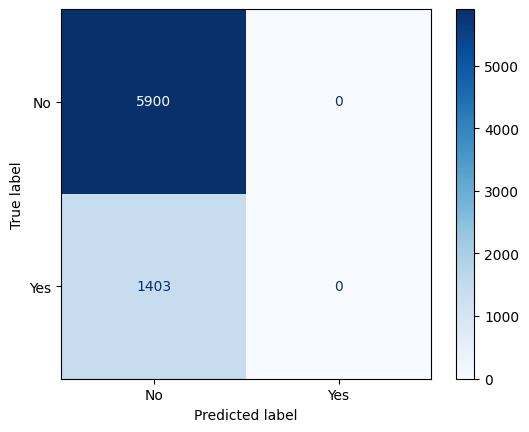

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
cm_display.plot(cmap='Blues')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.81      1.00      0.89      5900
         Yes       0.00      0.00      0.00      1403

    accuracy                           0.81      7303
   macro avg       0.40      0.50      0.45      7303
weighted avg       0.65      0.81      0.72      7303



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Subscription_type'] = label_encoder.fit_transform(df['Subscription_type'])
df.head()

,Age,Gender,Time_on_platform,Devices_connected,Subscription_type,Num_streaming_services,Num_active_profiles,Avg_rating,Churned,User_id
0,49.0,1,4700.0,3.0,0,0.0,3,0,No,a271aa56-bcfc-4f0a-91f7-b773de6b86a4
1,69.0,0,6107.0,2.0,2,0.0,1,2,No,fe14b048-770b-4619-8ec6-485b0969ae31
2,44.0,1,6374.0,3.0,1,1.0,1,1,Yes,0283dffd-6684-4a05-9c6f-c02098a6849d
3,26.0,1,0.0,5.0,0,0.0,2,0,No,c316f2f5-3403-4a0a-82c2-c98e4b3379d2
5,54.0,1,3024.0,2.0,0,0.0,1,0,No,a1df3a13-9255-4d00-8a9d-20565fefaab9


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Churned', 'User_id'])
y = df['Churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Churned', 'User_id'])
y = df['Churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:

y_pred = log_reg.predict(X_test)


In [ ]:

df_test = X_test.copy()
df_test['Predicted_Churned'] = y_pred


<ipython-input-34-d678ff9c2a7e>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_pred = pd.Series(y_pred).replace({'No': 0, 'Yes': 1})


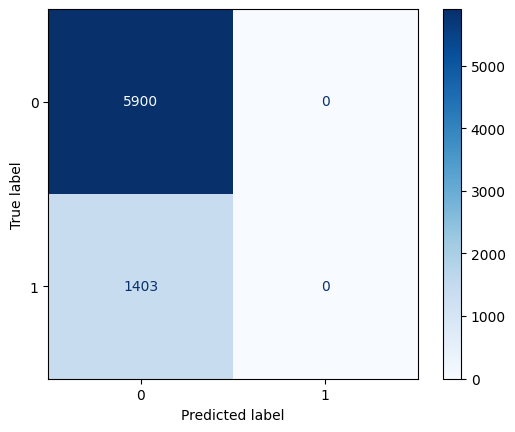

In [ ]:
import pandas as pd

# Substituindo 'No' por 0 e 'Yes' por 1 em y_test (que é uma Series)
y_test = y_test.replace({'No': 0, 'Yes': 1})

# Se y_pred for um ndarray, podemos convertê-lo para uma Series antes de fazer a substituição
y_pred = pd.Series(y_pred).replace({'No': 0, 'Yes': 1})

# Garantir que ambos sejam inteiros
y_test = y_test.astype(int)
y_pred = y_pred.astype(int)

# Criando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot(cmap='Blues')


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definindo o modelo
rf_model = RandomForestClassifier()

# Definindo os parâmetros para o grid search
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árvores
    'max_depth': [None, 10, 20, 30],  # Profundidade máxima das árvores
    'min_samples_split': [2, 5, 10],  # Número mínimo de amostras necessárias para dividir um nó
    'min_samples_leaf': [1, 2, 4],  # Número mínimo de amostras necessárias para ser um nó folha
}

# Montando o GridSearch
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)


In [ ]:
param_grid = {
    'n_estimators': [50, 100],  # Menos árvores
    'max_depth': [None, 10],     # Profundidade máxima menor
}


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definindo o modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definindo o grid de parâmetros
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árvores na floresta
    'max_depth': [None, 10, 20],      # Profundidade máxima das árvores
    'min_samples_split': [2, 5],      # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2],       # Número mínimo de amostras em um nó folha
    'bootstrap': [True, False]        # Usar bootstrap ou não
}

# Realizando o grid search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)


In [ ]:
# Ajustando o modelo com o grid search
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 4],
                         'n_estimators': [50, 100]},
             verbose=1)

In [ ]:
# Melhor modelo encontrado pelo GridSearch
best_rf_model = grid_search.best_estimator_

# Exibindo os melhores parâmetros
print("Melhores parâmetros:", grid_search.best_params_)


Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
# Realizando as predições
y_pred = best_rf_model.predict(X_test)


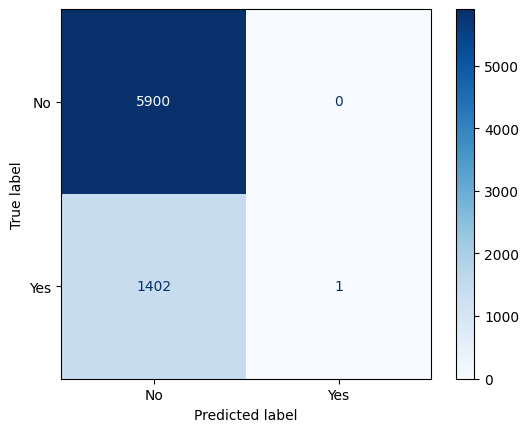

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Converter y_pred para inteiros (0 e 1)
y_pred_int = np.where(y_pred == 'Yes', 1, 0)

# Garantir que y_test também seja inteiro (se ainda não for)
y_test_int = y_test.astype(int)

# Gerar matriz de confusão
cm = confusion_matrix(y_test_int, y_pred_int, labels=[0, 1])

# Exibir matriz de confusão
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
cm_display.plot(cmap='Blues')



In [ ]:
from sklearn.metrics import classification_report

# Relatório completo de métricas
print(classification_report(y_test_int, y_pred_int, target_names=['No', 'Yes']))


              precision    recall  f1-score   support

          No       0.81      1.00      0.89      5900
         Yes       1.00      0.00      0.00      1403

    accuracy                           0.81      7303
   macro avg       0.90      0.50      0.45      7303
weighted avg       0.84      0.81      0.72      7303

